In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pickle
from matplotlib.colors import ListedColormap

## Problem: Number Partition



As an initial problem we study the number partitioning problem. Given a set $S$ of $N$ positive numbers 
$S = \{ n_{0}, \ldots , n_{N-1}\}$, is there a partition of $S$ into $P$ disjoint subsets $\{ R_0, \ldots , R_{P-1} \}$, such that the sum of values in 
each set is the same. I.e., can a set of $N$ assets with values $n_0, \ldots , n_{N-1}$ fairly be distributed between $P$ parties?

The Quadratic Unconstrained Binary Optimization model can be formulated in the following way

\begin{align}
	H = \sum_{p=0}^{P-1}  \left( \sum_{i=0}^{N-1} n_{i} x_{i, p} - \frac{1}{P} \sum_{i=0}^{N-1} n_{i} \right)^2 + M \sum_{i=0}^{N-1}  \left( 1- \sum_{p=0}^{P-1} x_{i, p} \right)^2 \, ,
\end{align}

and the decision variable $x_{i, p} \in \{0,1\}$ is defined as

\begin{align}
	x_{i, p} = 
    \begin{cases}
	1 & \text{if number } n_i \text{ of set } S \text{ is in set } R_p \\
	0 & \text{else}
    \end{cases} \, .
\end{align}

- $P=4$: Number of subsets.
- $N$: Number of values in set $S$.
- ${\rm{bits}} = N \cdot P$: Number of bits needed to represent problem QUBO.
- $M$: Penalty factor.

In [3]:
### nice plots

import matplotlib as matp

matp.rcParams['mathtext.fontset'] = 'stix'
matp.rcParams['font.family'] = 'STIXGeneral'

## Read data for analysis

In [4]:
class Datas():
    def __init__(self, bits_idx_list, n_temp_scalers, n_eta_runs):
        Ps = np.arange(2, 17, 2)
        Ns = 8 * Ps
        self.Ns = Ns[bits_idx_list]
        self.Ps = Ps[bits_idx_list]
        self.bits = Ns[bits_idx_list] * Ps[bits_idx_list]
        vseeds = range(42, 52)

        self.vseeds = vseeds
        self.n_vseeds = len(vseeds)
        self.temperature_scalers = [1, 10, 100, 1000]
        self.temperature_base = 1e3
        self.temperatures_labels = ["$10^3$", "$10^4$", "$10^5$", "$10^6$"] # = temp_base * temp_scalers

        self.M_star = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, n_eta_runs))
        self.M_L1 = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers, n_eta_runs))
        self.temperature = np.ndarray((len(bits_idx_list), len(vseeds), n_temp_scalers))
        self.eta_required = np.array([.25, .5, .75])

In [5]:
# change last_Nidx to extend your dataset as you collect more data

last_Nidx = 7
N_idxs = np.arange(last_Nidx+1)
n_temp_scalers = 4
n_eta_runs = 3
data = Datas(N_idxs, n_temp_scalers, n_eta_runs)


directory = "../data/Ms_NPP/"

for N_idx in N_idxs: # if N_idxs start from 0. Else, write "for N_idx_idx, N_idx in enumerate(N_idxs):"
    filename = directory + f"results-N={data.Ns[N_idx]}_P={data.Ps[N_idx]}.txt"
    file = open(filename, "rb")
    D = pickle.load(file)
    file.close()

    assert len(D.keys()) == len(data.vseeds)
    for seed_idx, seed in enumerate(D):
        assert len(D[seed].keys()) == n_temp_scalers
        for temp_idx, temp_scaler in enumerate(list(D[seed])):
            data.temperature[N_idx, seed_idx, temp_idx] = D[seed][temp_scaler]["temperature"]
            assert len(D[seed][temp_scaler].keys()) == n_eta_runs + 1  # the +1 is for temperature
            for eta_run_idx, eta_req in enumerate(list(D[seed][temp_scaler])[1:]):
                data.M_star[N_idx, seed_idx, temp_idx, eta_run_idx] = D[seed][temp_scaler][eta_req]["M_star"]
                data.M_L1[N_idx, seed_idx, temp_idx, eta_run_idx] = D[seed][temp_scaler][eta_req]["M_L1"]

## $log( M_{\ell_1} / M^*)(n_{bits})$ for different temperatures

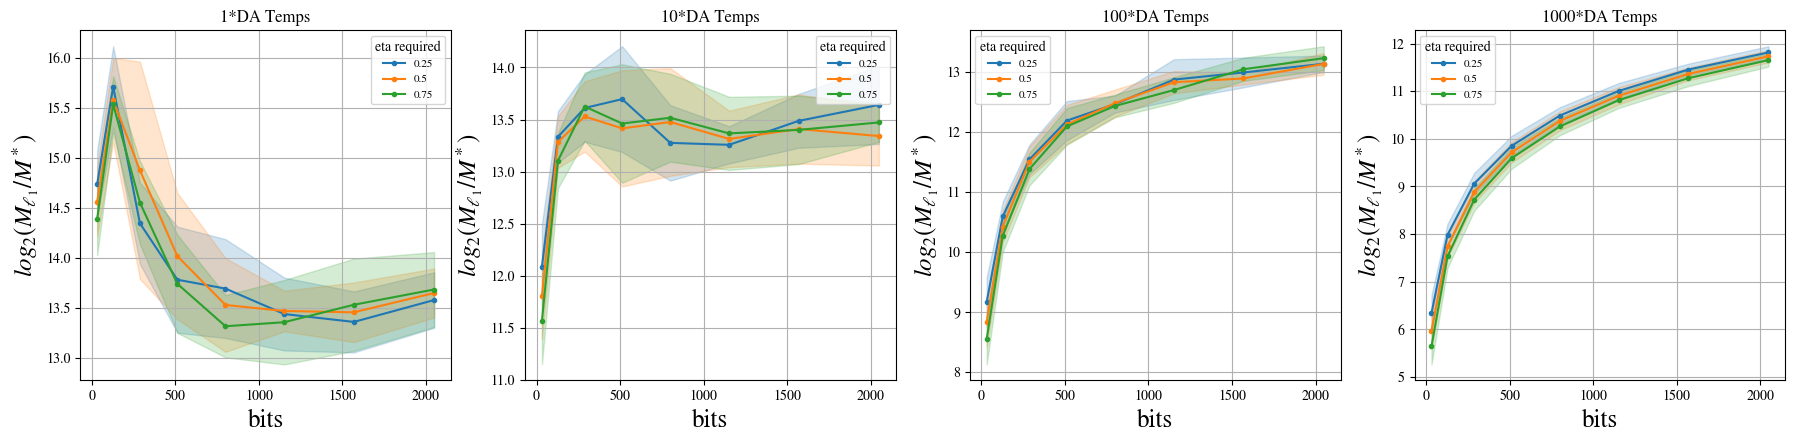

In [6]:
fig = plt.figure(figsize=(22,10))
for temp_idx in range(n_temp_scalers):
    logs = np.mean(  np.log2(data.M_L1[:, :, temp_idx, ...] / data.M_star[:, :, temp_idx, ...])  , axis = 1)
    logs_std = np.std(  np.log2(data.M_L1[:, :, temp_idx, ...] / data.M_star[:, :, temp_idx, ...]) , axis = 1)
    
    ax = fig.add_subplot(2,4,temp_idx+1)
    ax.set_xlabel('bits', fontsize = 18)
    ax.set_ylabel(r'$log_2( M_{\ell_1} / M^*)$', fontsize = 18)

    for eta_run_idx in np.arange(n_eta_runs):
        ax.plot(data.bits, logs[:, eta_run_idx], "-", marker = ".", color = f"C{eta_run_idx}", label=str(data.eta_required[eta_run_idx]))
        ax.fill_between(data.bits, logs[:, eta_run_idx] - logs_std[:, eta_run_idx], logs[:, eta_run_idx] + logs_std[:, eta_run_idx], color = f"C{eta_run_idx}", alpha=.2)
    #ax.set_xscale("log")
    ax.set_title(f"{data.temperature_scalers[temp_idx]}*DA Temps")
    ax.legend(title = "eta required", fontsize = 8, loc='best')
    ax.grid()
plt.show()

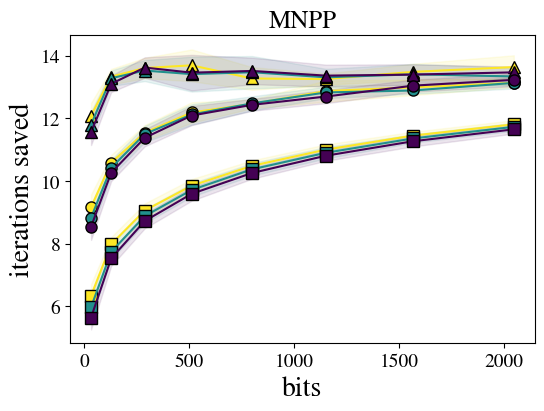

In [ ]:
markers = ["x", "^", "o", "s"]
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, n_eta_runs))) 

exc_temp = 1

fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax.set_xlabel(r'bits', fontsize = 20)
#ax.set_ylabel(r'$log_2( M_{\ell_1} / M^*)$', fontsize = 20)
ax.set_ylabel(r'iterations saved', fontsize = 20)
ax.tick_params(axis='both', labelsize=14)
# ax.set_xticks(data.bits)
for temp_idx in range(exc_temp, n_temp_scalers):
    for eta_run_idx in np.arange(n_eta_runs):
        logs = np.mean(  np.log2(data.M_L1[:, :, temp_idx, eta_run_idx] / data.M_star[:, :, temp_idx, eta_run_idx])  , axis = 1)
        logs_std = np.std(  np.log2(data.M_L1[:, :, temp_idx, eta_run_idx] / data.M_star[:, :, temp_idx, eta_run_idx]) , axis = 1)
        ax.plot(data.bits, logs, "-", color = discr_colors.colors[eta_run_idx], marker = markers[temp_idx], markersize = 8, markeredgecolor="k",
                 label=str(data.eta_required[eta_run_idx]) + f" ; {data.temperature_scalers[temp_idx]}")
        ax.fill_between(data.bits, logs - logs_std, logs + logs_std, color = discr_colors.colors[eta_run_idx], alpha=.1)

# # ---- Concise legend ----
# eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, data.eta_required)]
# temp_handles = [Line2D([0], [0], color="w", markersize = 8,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers[exc_temp:], data.temperatures_labels[exc_temp:])]
# all_handles = eta_handles + temp_handles
# all_labels  = [h.get_label() for h in all_handles]
# ax.legend(handles=all_handles, labels=all_labels, title=r"      $\eta_{r}$            Temp.", title_fontsize=14, fontsize=13, loc="best", ncol=2)
# # --------
# ax.set_xscale("log")
ax.set_title(f"MNPP", fontsize = 18)
plt.show()

# fig.savefig("../plots_paper/iters_saved/MNPP.pdf", bbox_inches='tight', format="pdf")